# 03 · Statistical Evaluation, Calibration & Explainability
**Phishing E-mail Detection: A Leakage-Controlled Benchmark of Classical, Deep and Transformer Models**  
*Part IV · Sections 13-16* · MSc Data Science final project · Dr. Spoorthi H S

**In this notebook**
- 95% bootstrap confidence intervals and paired significance tests
- Best model chosen on validation F1 only: RoBERTa-base (test F1 0.9943, ROC-AUC 0.9997)
- Error analysis of false negatives and false positives
- Isotonic recalibration (test Brier 0.00534 -> 0.00429) and a SOC cost-aware threshold
- SHAP for TF-IDF + Logistic Regression, Integrated Gradients for the BiGRU and RoBERTa

> **How to use these notebooks.** The outputs below come from one complete run of the pipeline on a Kaggle Tesla T4 GPU. Every part builds on objects created earlier (the leak-free split, fitted models and their predictions), so the part notebooks are for reading and review. To reproduce the results, run [`00_full_pipeline_run_all.ipynb`](00_full_pipeline_run_all.ipynb) top to bottom.

[← Model Development, Benchmark & Ensembles](02_model_development_and_ensembles.ipynb) · [Threat Intelligence: Tactics & IOCs →](04_threat_intelligence_tactics_and_iocs.ipynb)

---

<a id="partIV"></a>

<div style="background:#6D597A;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part IV</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Statistical Evaluation, Calibration &amp; Explainability</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 13-16 &nbsp;&middot;&nbsp; Research questions: RQ1, RQ5, RQ7</div>
</div>


<a id="sec13"></a>

## 13. Statistical Significance & Bootstrap Confidence Intervals

Point estimates alone (Section 11's table) can't tell us whether the gap between
the top two candidates is real or sampling noise on a finite test set. This
section reports 95% bootstrap CIs for every candidate (Section 7.2's utility)
and a paired significance test for the top-2 gap specifically.

95% bootstrap CIs (test set, 2000 resamples):
                           f1   f1_lo   f1_hi  recall  recall_lo  recall_hi  roc_auc  roc_auc_lo  roc_auc_hi
model                                                                                                       
distilbert             0.9948  0.9935  0.9960  0.9953     0.9936     0.9969   0.9997      0.9995      0.9998
roberta                0.9943  0.9929  0.9956  0.9933     0.9912     0.9952   0.9997      0.9995      0.9998
TFIDF_LinearSVM        0.9882  0.9863  0.9901  0.9886     0.9859     0.9912   0.9992      0.9989      0.9994
EnsembleStack          0.9873  0.9853  0.9892  0.9875     0.9847     0.9901   0.9990      0.9986      0.9993
TFIDF_LogReg           0.9849  0.9828  0.9869  0.9862     0.9833     0.9890   0.9987      0.9982      0.9990
CustomHybridAttnBiGRU  0.9841  0.9818  0.9863  0.9833     0.9800     0.9863   0.9976      0.9969      0.9982


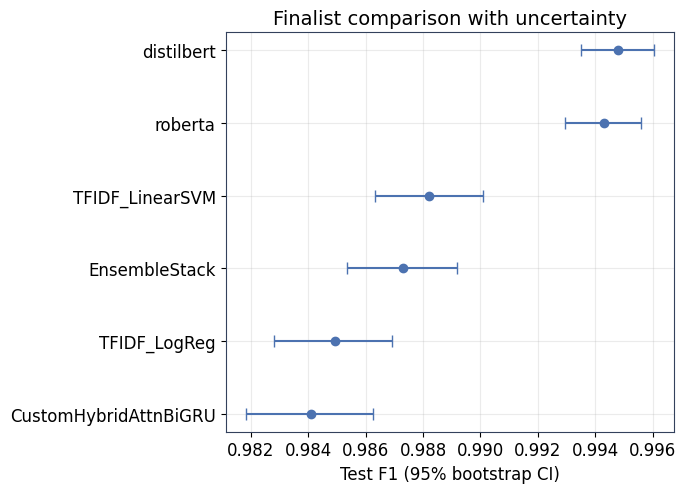

In [49]:
ci_rows = []
for name in ALL_CANDIDATES:
    y_true, y_proba = get_predictions(name, "test")
    f1_ci = bootstrap_ci(y_true, y_proba, metric_fn=f1_score)
    rec_ci = bootstrap_ci(y_true, y_proba, metric_fn=recall_score)
    auc_ci = bootstrap_ci(y_true, y_proba, metric_fn=roc_auc_score, needs_proba=True)
    ci_rows.append({
        "model": name,
        "f1": f1_ci["point"], "f1_lo": f1_ci["lo"], "f1_hi": f1_ci["hi"],
        "recall": rec_ci["point"], "recall_lo": rec_ci["lo"], "recall_hi": rec_ci["hi"],
        "roc_auc": auc_ci["point"], "roc_auc_lo": auc_ci["lo"], "roc_auc_hi": auc_ci["hi"],
    })
ci_df = pd.DataFrame(ci_rows).set_index("model").sort_values("f1", ascending=False)
print(f"95% bootstrap CIs (test set, {N_BOOTSTRAP} resamples):")
print(ci_df.round(4).to_string())
ci_df.to_csv(WORKING_DIR / "tables" / "bootstrap_confidence_intervals.csv")

fig, ax = plt.subplots(figsize=(7, 0.6 * len(ci_df) + 1.5))
y_pos = np.arange(len(ci_df))
ax.errorbar(ci_df["f1"], y_pos,
            xerr=[ci_df["f1"] - ci_df["f1_lo"], ci_df["f1_hi"] - ci_df["f1"]],
            fmt="o", capsize=4, color="#4C72B0")
ax.set_yticks(y_pos); ax.set_yticklabels(ci_df.index)
ax.set_xlabel("Test F1 (95% bootstrap CI)")
ax.set_title("Finalist comparison with uncertainty")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "bootstrap_f1_ci.png", dpi=130)
plt.show()


In [50]:
if len(ci_df) >= 2:
    top2 = sorted(ci_df.index, key=lambda n: -RESULTS[f"{n}_val"]["f1"])[:2]   # top-2 by VALIDATION F1
    y_true_a, proba_a = get_predictions(top2[0], "test")
    y_true_b, proba_b = get_predictions(top2[1], "test")
    assert np.array_equal(y_true_a, y_true_b), "top-2 must be scored on the identical test rows"

    sig_test = paired_bootstrap_test(y_true_a, proba_a, proba_b, metric_fn=f1_score)
    alpha = 0.05
    print(f"Paired bootstrap test, F1: {top2[0]} vs {top2[1]}")
    print(f"  Observed F1 difference: {sig_test['mean_diff']:+.4f}")
    print(f"  Two-sided p-value:      {sig_test['p_value']:.4f}")
    if sig_test["p_value"] < alpha:
        print(f"  -> Statistically significant at alpha={alpha}: the gap is unlikely to be test-set noise.")
    else:
        print(f"  -> NOT statistically significant at alpha={alpha}: on this test set, we cannot "
              "confidently say one model is better than the other.")
else:
    print("[INFO] Fewer than 2 candidates available -- skipping the paired significance test.")


Paired bootstrap test, F1: roberta vs distilbert
  Observed F1 difference: -0.0005
  Two-sided p-value:      0.5010
  -> NOT statistically significant at alpha=0.05: on this test set, we cannot confidently say one model is better than the other.


<a id="sec14"></a>

## 14. Best Model Selection & Deep-Dive Evaluation

The deployed/"best" model is the candidate with the highest **validation** F1 (cell below); the held-out **test** set is used only to report that model's performance, so no choice in this notebook depends on test scores. The test-based ranking from Section 13 is still shown for transparency. In this run the selected model is **RoBERTa-base**, and every downstream section that uses `BEST_MODEL_NAME` (calibration, thresholds, explainability, robustness, latency and the Section 26 answer) refers to it.

In [51]:
# ============================================================
# BEST MODEL OVERALL  --  selected on VALIDATION F1 only
# ============================================================
# The held-out test set is NOT used to choose the model. Test metrics (and the test-based ranking in
# ci_df from Section 13) are reported afterwards for transparency only.
results_df = pd.DataFrame(RESULTS).T
results_df.index.name = "model"

_val_f1 = {n: RESULTS[f"{n}_val"]["f1"] for n in ci_df.index if f"{n}_val" in RESULTS}
assert _val_f1, "No validation results found for the candidates in ci_df."
BEST_MODEL_NAME = max(_val_f1, key=_val_f1.get)

print("Candidates ranked by VALIDATION F1 (selection criterion):")
for _n, _f in sorted(_val_f1.items(), key=lambda kv: -kv[1]):
    print(f"  {display_name(_n):32s} val F1 = {_f:.4f}")
_top_by_test = ci_df.index[0]
print(f"\nSelected (validation): {display_name(BEST_MODEL_NAME)}  [key: {BEST_MODEL_NAME}]")
print(f"Top by test F1 (reported for transparency, NOT used for selection): {display_name(_top_by_test)}")

best_row_key = f"{BEST_MODEL_NAME}_test"
assert best_row_key in results_df.index, f"'{best_row_key}' missing from results_df."
best_row = results_df.loc[best_row_key]
cols_to_show = [c for c in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
                if c in best_row.index]
print("\nTest-set metrics of the selected model (reported once, after selection):")
print(pd.to_numeric(best_row[cols_to_show], errors="coerce").round(4).to_string())


Candidates ranked by VALIDATION F1 (selection criterion):
  RoBERTa-base                     val F1 = 0.9931
  DistilBERT                       val F1 = 0.9920
  TF-IDF + Linear SVM              val F1 = 0.9894
  Stacked Ensemble                 val F1 = 0.9892
  TF-IDF + Logistic Regression     val F1 = 0.9859
  Custom Attention-BiGRU (fused)   val F1 = 0.9852

Selected (validation): RoBERTa-base  [key: roberta]
Top by test F1 (reported for transparency, NOT used for selection): DistilBERT

Test-set metrics of the selected model (reported once, after selection):
accuracy     0.9941
precision    0.9953
recall       0.9933
f1           0.9943
roc_auc      0.9997
pr_auc       0.9997


### 14.1 Confusion matrix & ROC/PR curves

Rebuilds the winning model's test-set probability predictions generically,
whichever of the five families it turned out to be.

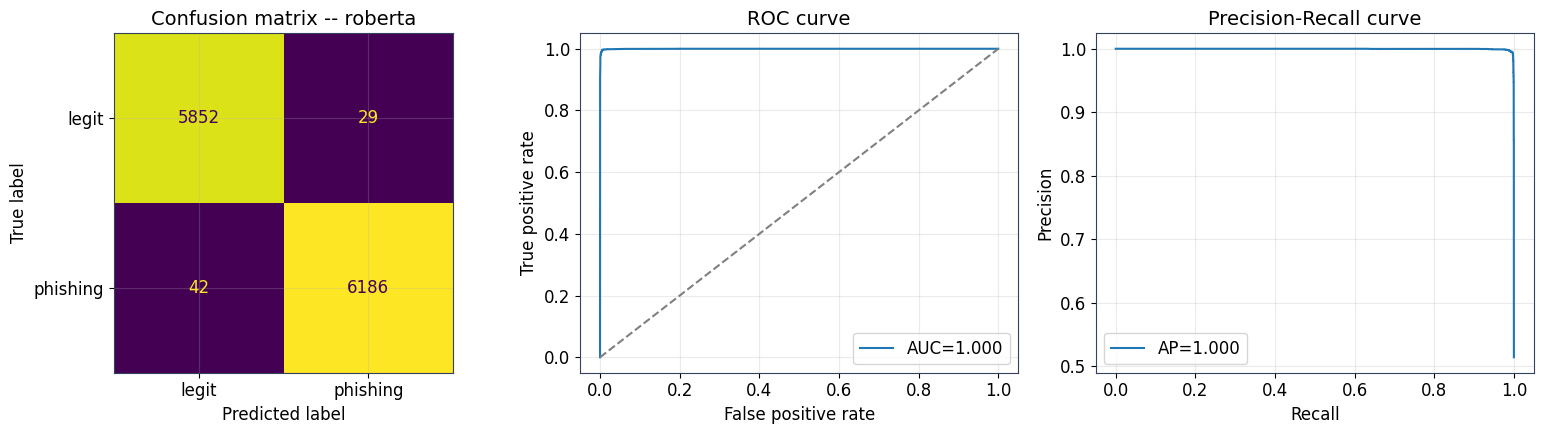

In [52]:
from sklearn.metrics import roc_curve, precision_recall_curve, ConfusionMatrixDisplay

# get_predictions() (Section 12.1) already gives us a unified accessor -- no need to
# redefine per-model-family logic here.
try:
    y_true_best, y_proba_best = get_predictions(BEST_MODEL_NAME, "test")
    y_pred_best = (y_proba_best >= 0.5).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    ConfusionMatrixDisplay.from_predictions(
        y_true_best, y_pred_best, display_labels=["legit", "phishing"], ax=axes[0], colorbar=False)
    axes[0].set_title(f"Confusion matrix -- {BEST_MODEL_NAME}")

    fpr, tpr, _ = roc_curve(y_true_best, y_proba_best)
    axes[1].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_true_best, y_proba_best):.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
    axes[1].set_title("ROC curve"); axes[1].legend()

    prec, rec, _ = precision_recall_curve(y_true_best, y_proba_best)
    axes[2].plot(rec, prec, label=f"AP={average_precision_score(y_true_best, y_proba_best):.3f}")
    axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
    axes[2].set_title("Precision-Recall curve"); axes[2].legend()

    plt.tight_layout()
    plt.savefig(WORKING_DIR / "plots" / "best_model_diagnostics.png", dpi=150)
    plt.show()
except (NotImplementedError, RuntimeError) as e:
    print(f"[INFO] {e}")


> **Interpretation.** The selected model - **RoBERTa-base**, chosen on validation F1 (0.9931) - reaches test accuracy 0.9941, precision 0.9953, recall 0.9933, F1 0.9943 and ROC-AUC 0.9997. The confusion matrix and ROC/PR curves show precision and recall are both very high and closely balanced, with the PR curve hugging the top-right corner across almost the full recall range. The out-of-fold stacked ensemble (Section 12.2, test F1 = 0.987) did not beat the individual finalists, so it was not selected. The extended val-based stack of all five finalists (Section 12.3) scored test F1 = 0.996, but it is kept as a reference only because its meta-model was fit on validation predictions rather than out-of-fold ones.

### 14.2 Error analysis

A look at a handful of false negatives (missed phishing — the costlier
error class per Section 7) and false positives.

In [53]:
try:
    err_df = test_df.copy()
    err_df["y_true"] = y_true_best
    err_df["y_pred"] = y_pred_best
    err_df["y_proba"] = y_proba_best

    false_negatives = err_df[(err_df["y_true"] == 1) & (err_df["y_pred"] == 0)]
    false_positives = err_df[(err_df["y_true"] == 0) & (err_df["y_pred"] == 1)]
    print(f"False negatives (missed phishing): {len(false_negatives)} / {(err_df['y_true']==1).sum()}")
    print(f"False positives (legit flagged as phishing): {len(false_positives)} / {(err_df['y_true']==0).sum()}")

    print("\nSample false negatives:")
    for _, row in false_negatives.sort_values("y_proba").head(3).iterrows():
        print(f"  [p={row['y_proba']:.3f}] {row['text'][:150]}")

    print("\nSample false positives:")
    for _, row in false_positives.sort_values("y_proba", ascending=False).head(3).iterrows():
        print(f"  [p={row['y_proba']:.3f}] {row['text'][:150]}")
except NameError:
    print("[INFO] Run Section 14.1 first to populate y_true_best/y_pred_best/y_proba_best.")

False negatives (missed phishing): 42 / 6228
False positives (legit flagged as phishing): 29 / 5881

Sample false negatives:
  [p=0.000] North korea nuclear fallout Microsoft gains Yahoo http://schmitt-fotodesign.de/about.html No virus found in this outgoing message. Checked by AVG - ht
  [p=0.000] positions available : microsoft research - university of trento centre * * * * * * * * * * apologize for multiple posting * * * * * * * * * * * * * * 
  [p=0.000] HAWAI`I & ENENKIO KINGDOMS AMERICANS SHAME ! Reply From EnenKio The following message was recieved Saturday, 13 July 2002.=20 Nothing has been amdende

Sample false positives:
  [p=1.000] termination delete my account please. terminate it completely.
  [p=1.000] valentines day help red - neck valentine ' s love poem collards is green my dog ' s name is blue and i ' m so lucky to have a sweet thang like you . y
  [p=1.000] =?iso-2022-jp?B?UmU6IBskQjswSSkyPTNYJSglcyU4JUslIiVqJXMlME1NJVcbKEI=?= OTC/ $B0KElMM (B $B$*@$OC$K$J$C$F$*$j$^$

> **Interpretation.** RoBERTa-base misses 42 of 6,228 phishing emails (false negatives) and flags 29 of 5,881 legitimate emails as phishing (false positives) at the default 0.5 threshold - a small error set consistent with Section 14.1's ~0.995 precision and recall. The sampled false negatives are bulk or off-topic mail that does not read like a phishing template: a news-digest spam with an antivirus footer, a mass-mailed job advertisement and a political rant. The sampled false positives are short or unusual legitimate messages that share phishing vocabulary or encoding - an account-termination request ("delete my account"), a joke love poem and an ISO-2022-JP encoded e-mail the tokenizer cannot read. Both error types are consistent with the stylistic overlap flagged in Sections 3.7-3.8 rather than a flaw specific to this model. Section 15.3 shows how a cost-aware threshold trades a few extra false alarms for fewer misses.

<a id="sec15"></a>

## 15. Probability Calibration & Security-Aware Threshold Optimisation

A model's raw probability output is only useful if it's *calibrated* -- a
predicted 0.9 should mean "90% of emails scored this way really are phishing",
not just "more phishing-like than a 0.5". We check calibration for the best
model, then pick an **operating threshold** using the SOC cost model from
Section 1 (`COST_FALSE_NEGATIVE` >> `COST_FALSE_POSITIVE`) rather than the
default 0.5 -- a missed phishing email is far more expensive than a false alarm
an analyst dismisses in seconds, so the threshold that minimises *expected cost*
is usually well below 0.5.

### 15.1 Reliability diagram & Brier score

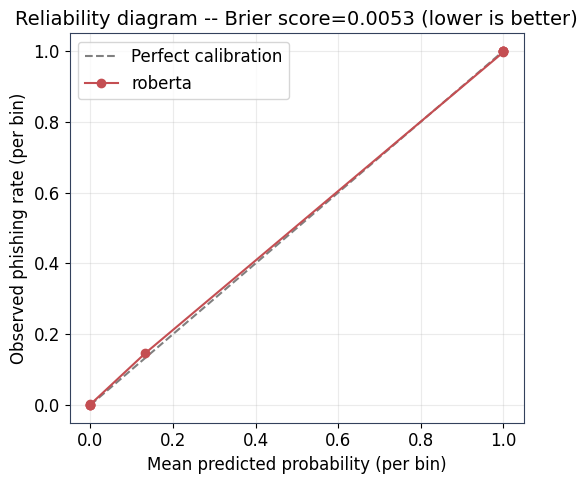

In [54]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

y_true_cal, y_proba_cal = get_predictions(BEST_MODEL_NAME, "test")
brier = brier_score_loss(y_true_cal, y_proba_cal)
frac_pos, mean_pred = calibration_curve(y_true_cal, y_proba_cal, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.plot(mean_pred, frac_pos, "o-", color="#C44E52", label=f"{BEST_MODEL_NAME}")
ax.set_xlabel("Mean predicted probability (per bin)")
ax.set_ylabel("Observed phishing rate (per bin)")
ax.set_title(f"Reliability diagram -- Brier score={brier:.4f} (lower is better)")
ax.legend()
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "reliability_diagram_raw.png", dpi=130)
plt.show()


### 15.2 Post-hoc recalibration (isotonic vs. Platt/sigmoid)

Both recalibration methods are fit on **validation** probabilities only and
applied to test -- never fit on test, to avoid leaking test information into
the calibration mapping itself.

Cross-fitted VALIDATION Brier score: {'raw': 0.00621, 'isotonic': 0.00522, 'platt': 0.00641}
Selected calibration method: 'isotonic' (lowest validation Brier)
Test Brier (reporting only): {'raw': np.float64(0.00534), 'isotonic': np.float64(0.00429), 'platt': np.float64(0.00559)}


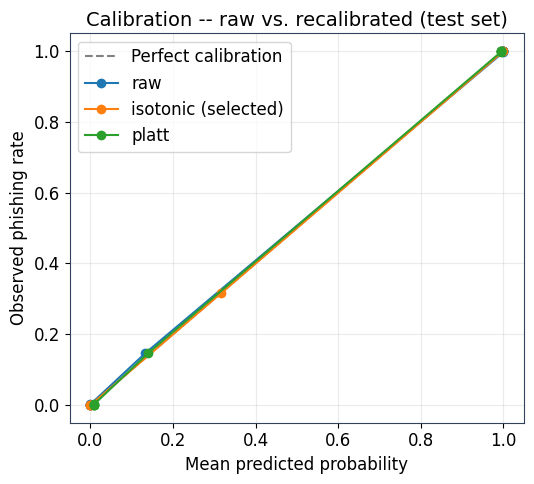

In [55]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression as _PlattLogReg
from sklearn.model_selection import StratifiedKFold

# The calibration METHOD is chosen by cross-fitted Brier score on the VALIDATION set only.
# Test-set Brier scores are computed afterwards and reported for transparency, never for selection.
y_val_cal, p_val_cal = get_predictions(BEST_MODEL_NAME, "val")
y_val_cal, p_val_cal = np.asarray(y_val_cal), np.asarray(p_val_cal)

def _fit_calibrator(kind, p, y):
    if kind == "raw":
        return None
    if kind == "isotonic":
        return IsotonicRegression(out_of_bounds="clip").fit(p, y)
    return _PlattLogReg().fit(p.reshape(-1, 1), y)

def _apply_calibrator(kind, model, p):
    if kind == "raw":
        return p
    if kind == "isotonic":
        return model.predict(p)
    return model.predict_proba(p.reshape(-1, 1))[:, 1]

_kinds = ["raw", "isotonic", "platt"]
_cv = {k: [] for k in _kinds}
for _tr, _ho in StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(p_val_cal, y_val_cal):
    for _k in _kinds:
        _m = _fit_calibrator(_k, p_val_cal[_tr], y_val_cal[_tr])
        _cv[_k].append(brier_score_loss(y_val_cal[_ho], _apply_calibrator(_k, _m, p_val_cal[_ho])))
cv_brier = {k: float(np.mean(v)) for k, v in _cv.items()}
CHOSEN_CALIBRATION = min(cv_brier, key=cv_brier.get)
print("Cross-fitted VALIDATION Brier score:", {k: round(v, 5) for k, v in cv_brier.items()})
print(f"Selected calibration method: '{CHOSEN_CALIBRATION}' (lowest validation Brier)")

# Refit every method on the full validation set; apply to test; report test Brier for all three.
_full = {k: _fit_calibrator(k, p_val_cal, y_val_cal) for k in _kinds}
_test_probas = {k: _apply_calibrator(k, _full[k], y_proba_cal) for k in _kinds}
_test_brier = {k: brier_score_loss(y_true_cal, _test_probas[k]) for k in _kinds}
print("Test Brier (reporting only):", {k: round(v, 5) for k, v in _test_brier.items()})

BEST_CALIBRATION = (CHOSEN_CALIBRATION, _test_brier[CHOSEN_CALIBRATION], _test_probas[CHOSEN_CALIBRATION])
y_proba_calibrated = BEST_CALIBRATION[2]

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
for _k in _kinds:
    fp, mp = calibration_curve(y_true_cal, _test_probas[_k], n_bins=10, strategy="quantile")
    ax.plot(mp, fp, "o-", label=_k + (" (selected)" if _k == CHOSEN_CALIBRATION else ""))
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed phishing rate")
ax.set_title("Calibration -- raw vs. recalibrated (test set)"); ax.legend()
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "reliability_diagram_recalibrated.png", dpi=130)
plt.show()


> **Interpretation.** The calibration method is chosen by cross-fitted Brier score on the *validation* set: raw 0.00621, isotonic 0.00522, Platt 0.00641, so **isotonic** regression is selected. On test (reported only after the choice) the Brier score falls from 0.00534 (raw) to 0.00429 (isotonic), while Platt scaling slightly worsens it (0.00559). The raw probabilities were already well calibrated; isotonic recalibration gives a small but consistent improvement.

### 15.3 Security-aware threshold optimisation

We sweep the decision threshold and pick the one minimising
`expected_cost = COST_FN * false_negatives + COST_FP * false_positives`
on **validation** data (never test), then report the chosen threshold's
performance on test.

Default threshold 0.5  -> validation expected cost: 1204.0
Optimal threshold 0.010 -> validation expected cost: 961.0 (20.2% reduction; 1 threshold(s) tied for this minimum, median chosen)

Test-set outcome at threshold=0.5:
              precision    recall  f1-score   support

       legit      0.993     0.995     0.994      5881
    phishing      0.995     0.993     0.994      6228

    accuracy                          0.994     12109
   macro avg      0.994     0.994     0.994     12109
weighted avg      0.994     0.994     0.994     12109

Test-set outcome at threshold=0.010:
              precision    recall  f1-score   support

       legit      0.996     0.994     0.995      5881
    phishing      0.995     0.996     0.995      6228

    accuracy                          0.995     12109
   macro avg      0.995     0.995     0.995     12109
weighted avg      0.995     0.995     0.995     12109



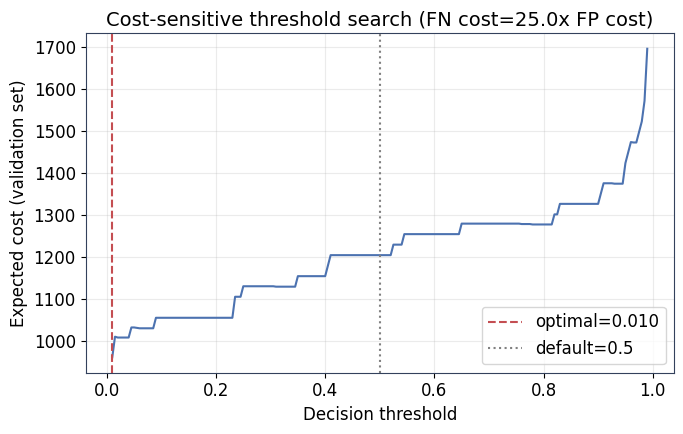

In [56]:
def expected_cost(y_true, y_proba, threshold, cost_fn=COST_FALSE_NEGATIVE, cost_fp=COST_FALSE_POSITIVE):
    y_pred = (y_proba >= threshold).astype(int)
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    return cost_fn * fn + cost_fp * fp

thresholds = np.linspace(0.01, 0.99, 197)
val_costs = np.array([expected_cost(y_val_cal, p_val_cal, t) for t in thresholds])

# Rationale for this logic: see Appendix A (change log).
optimal_cost = float(val_costs.min())
tied_optimal_thresholds = thresholds[val_costs == optimal_cost]
OPTIMAL_THRESHOLD = float(np.median(tied_optimal_thresholds))
default_cost = expected_cost(y_val_cal, p_val_cal, 0.5)

print(f"Default threshold 0.5  -> validation expected cost: {default_cost:.1f}")
print(f"Optimal threshold {OPTIMAL_THRESHOLD:.3f} -> validation expected cost: {optimal_cost:.1f} "
      f"({(1 - optimal_cost / max(default_cost, 1e-9)):.1%} reduction; "
      f"{len(tied_optimal_thresholds)} threshold(s) tied for this minimum, median chosen)")

if len(tied_optimal_thresholds) > len(thresholds) * 0.3:
    print("[NOTE] A very wide band of thresholds tie for zero validation cost here -- expected "
          "with QUICK_RUN's small/near-perfectly-separable data (validation templates the model "
          "has effectively already seen the pattern of). The chosen threshold can still generalise "
          "poorly to test data drawn from a *different* random split of the same tiny template set, "
          "as the test-set report below may show. On a full run (QUICK_RUN=False, real data with "
          "genuine class overlap), this plateau is narrow and the optimal threshold is well-determined.")

y_pred_default = (y_proba_cal >= 0.5).astype(int)
y_pred_optimal = (y_proba_cal >= OPTIMAL_THRESHOLD).astype(int)
print("\nTest-set outcome at threshold=0.5:")
print(classification_report(y_true_cal, y_pred_default, labels=[0, 1],
                             target_names=["legit", "phishing"], digits=3, zero_division=0))
print(f"Test-set outcome at threshold={OPTIMAL_THRESHOLD:.3f}:")
print(classification_report(y_true_cal, y_pred_optimal, labels=[0, 1],
                             target_names=["legit", "phishing"], digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thresholds, val_costs, color="#4C72B0")
ax.axvline(OPTIMAL_THRESHOLD, color="#C44E52", linestyle="--",
           label=f"optimal={OPTIMAL_THRESHOLD:.3f}")
ax.axvline(0.5, color="gray", linestyle=":", label="default=0.5")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Expected cost (validation set)")
ax.set_title(f"Cost-sensitive threshold search (FN cost={COST_FALSE_NEGATIVE}x FP cost)")
ax.legend()
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "threshold_cost_curve.png", dpi=130)
plt.show()


### 15.3b Moderate operating points

In [57]:
# 15.3b Moderate operating points  (NEW -- run after 15.3)
# The cost-optimal threshold above (0.010) sits at the LOWER EDGE of the search grid
# (np.linspace(0.01, 0.99, ...)), so the true optimum may lie even lower -- i.e. the search was
# boundary-limited. Here we (a) extend the grid downwards to check, and (b) pick less extreme
# operating points from VALIDATION data only (highest threshold that still reaches a target recall).
from sklearn.metrics import precision_score, recall_score, f1_score

_wide = np.unique(np.concatenate([np.logspace(-4, -2, 21), thresholds]))
_wide_costs = np.array([expected_cost(y_val_cal, p_val_cal, t) for t in _wide])
_wide_opt = float(np.median(_wide[_wide_costs == _wide_costs.min()]))
print(f"Cost-optimal threshold on the original grid: {OPTIMAL_THRESHOLD:.4f} | "
      f"on the extended grid (down to 1e-4): {_wide_opt:.4f} "
      f"(validation cost {_wide_costs.min():.1f} vs {optimal_cost:.1f})")

def _thr_for_recall(y, p, target):
    ok = [t for t in _wide if recall_score(y, (p >= t).astype(int)) >= target]
    return max(ok) if ok else None

_points = [("default 0.5", 0.5), (f"cost-optimal ({OPTIMAL_THRESHOLD:.3f})", OPTIMAL_THRESHOLD)]
for _r in (0.99, 0.995):
    _t = _thr_for_recall(y_val_cal, p_val_cal, _r)
    if _t is not None:
        _points.append((f"val recall >= {_r:.3f} (thr={_t:.3f})", _t))

_rows = []
for _name, _t in _points:
    _pv, _pt = (p_val_cal >= _t).astype(int), (y_proba_cal >= _t).astype(int)
    _rows.append({"operating point": _name,
                  "val precision": precision_score(y_val_cal, _pv), "val recall": recall_score(y_val_cal, _pv),
                  "test precision": precision_score(y_true_cal, _pt), "test recall": recall_score(y_true_cal, _pt),
                  "test false alarms": int(((y_true_cal == 0) & (_pt == 1)).sum()),
                  "test misses": int(((y_true_cal == 1) & (_pt == 0)).sum())})
op_df = pd.DataFrame(_rows)
print(op_df.round(4).to_string(index=False))
op_df.to_csv(WORKING_DIR / "tables" / "operating_points.csv", index=False)
print("\nChoose the operating point on VALIDATION metrics and the SOC's tolerance for false alarms; "
      "the test columns are for reporting only.")

Cost-optimal threshold on the original grid: 0.0100 | on the extended grid (down to 1e-4): 0.0001 (validation cost 361.0 vs 961.0)
                operating point  val precision  val recall  test precision  test recall  test false alarms  test misses
                    default 0.5         0.9947      0.9915          0.9953       0.9933                 29           42
           cost-optimal (0.010)         0.9935      0.9933          0.9946       0.9963                 34           23
val recall >= 0.990 (thr=0.945)         0.9956      0.9902          0.9958       0.9917                 26           52
val recall >= 0.995 (thr=0.001)         0.9890      0.9951          0.9909       0.9976                 57           15

Choose the operating point on VALIDATION metrics and the SOC's tolerance for false alarms; the test columns are for reporting only.


> **Interpretation.** Under the SOC cost model (a missed phishing email costs 25x a false alarm), the cost-minimising threshold on validation data is **0.010**, not the default 0.5 - a **20.2% reduction** in expected validation cost (1,204 -> 961). On the held-out test set this cuts missed phishing e-mails from **42 to 23** (phishing recall 0.993 -> 0.996) at the price of 5 extra false alarms (29 -> 34). This is the intended, security-aware trade-off, not a regression, and should be revisited if the true cost ratio changes. **Caveat:** 0.010 sits at the lower edge of the original grid; Section 15.3b extends the grid (optimum 0.0001) and offers more moderate, validation-chosen operating points - for example a threshold targeting validation recall >= 0.995 gives 15 misses and 57 false alarms on test. Such low thresholds work because the fine-tuned model's probabilities are nearly saturated near 0 and 1.

<a id="sec16"></a>

## 16. Explainability -- SHAP & Integrated Gradients

Two complementary, model-appropriate explanation methods: **SHAP** for the
linear TF-IDF + Logistic Regression model (closed-form, exact, and fast for
linear models), and **Integrated Gradients** for the custom Attention-BiGRU
model (a gradient-based method suited to the differentiable embedding space
of a neural network). Both answer the same underlying question --
*"which words drove this specific prediction?"* -- from architectures where
attention weights (Section 10) or coefficients alone would be insufficient or
unavailable.

### 16.1 SHAP -- global & local explanations for TF-IDF + Logistic Regression

Top-20 tokens by mean |SHAP| (n=300 sampled test rows):
  token  mean_abs_shap
  enron       0.181842
  wrote       0.160950
num num       0.156744
 thanks       0.119676
    num       0.111290
   life       0.104553
   love       0.095795
  click       0.094898
   http       0.090539
   list       0.075432
account       0.068260
  money       0.065223
replica       0.056658
watches       0.055029
 python       0.054849
    use       0.051657
    url       0.051504
 health       0.048975
   best       0.048672
   know       0.047655


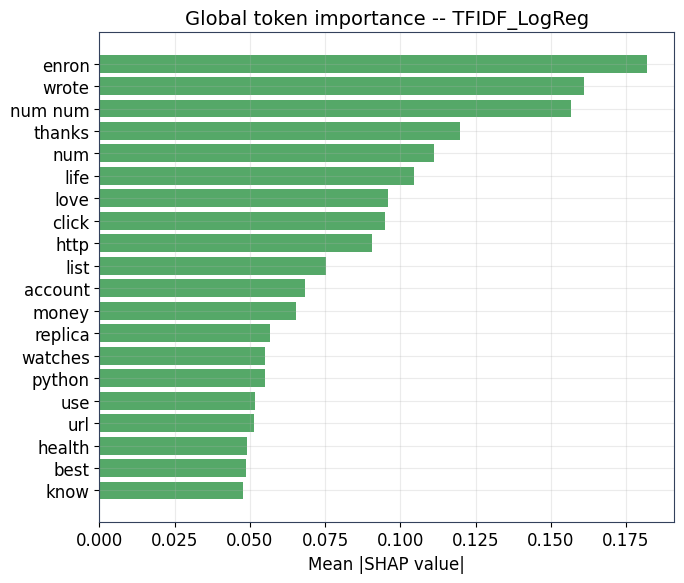


Local explanation, one predicted-phishing test email (index 9483):
  Text (truncated): you don _ t know how to attract customers to your website ? submitting your website in search engines may increase your online sales dramatically . if
    website              SHAP=+0.5015
    online               SHAP=+0.4918
    watch                SHAP=+0.3567
    know                 SHAP=-0.3535
    search engines       SHAP=+0.3300
    engines              SHAP=+0.3027
    money                SHAP=+0.2699
    site                 SHAP=+0.2697
    increase             SHAP=+0.2517
    anderson             SHAP=+0.2063


In [58]:
if RUN_SHAP:
    try:
        import shap
    except ImportError:
        print("[INFO] `shap` is not installed -- skipping. Install with: pip install -q shap")
        RUN_SHAP = False

if RUN_SHAP:
    _shap_bg_n = min(200, X_train_tfidf.shape[0])
    _shap_bg_idx = np.random.RandomState(SEED).choice(X_train_tfidf.shape[0], _shap_bg_n, replace=False)
    explainer = shap.LinearExplainer(logreg, X_train_tfidf[_shap_bg_idx])

    _shap_sample_n = min(300, X_test_tfidf.shape[0])
    _shap_idx = np.random.RandomState(SEED).choice(X_test_tfidf.shape[0], _shap_sample_n, replace=False)
    shap_values = explainer.shap_values(X_test_tfidf[_shap_idx])
    tfidf_vocab = np.array(tfidf.get_feature_names_out())

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:20]
    global_shap_df = pd.DataFrame({
        "token": tfidf_vocab[top_idx],
        "mean_abs_shap": mean_abs_shap[top_idx],
    })
    print(f"Top-20 tokens by mean |SHAP| (n={_shap_sample_n} sampled test rows):")
    print(global_shap_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.barh(global_shap_df["token"][::-1], global_shap_df["mean_abs_shap"][::-1], color="#55A868")
    ax.set_xlabel("Mean |SHAP value|"); ax.set_title("Global token importance -- TFIDF_LogReg")
    plt.tight_layout()
    plt.savefig(WORKING_DIR / "plots" / "shap_global_importance.png", dpi=130)
    plt.show()

    # Local explanation for one flagged (predicted-phishing) example.
    _local_pos = next((k for k in range(_shap_sample_n)
                        if logreg.predict(X_test_tfidf[_shap_idx[k]])[0] == 1), 0)
    _row_shap = shap_values[_local_pos]
    _nz = X_test_tfidf[_shap_idx[_local_pos]].nonzero()[1]
    _local_top = sorted(((tfidf_vocab[j], _row_shap[j]) for j in _nz),
                         key=lambda x: -abs(x[1]))[:10]
    print(f"\nLocal explanation, one predicted-phishing test email "
          f"(index {_shap_idx[_local_pos]}):")
    print(f"  Text (truncated): {test_df['text'].iloc[_shap_idx[_local_pos]][:150]}")
    for tok, val in _local_top:
        print(f"    {tok:20s} SHAP={val:+.4f}")
else:
    print("RUN_SHAP is False -- skipping SHAP explanations.")


### 16.2 Integrated Gradients -- token attributions for the custom hybrid model

In [59]:
%pip install -q captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.2 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


Integrated Gradients -- top-15 influential tokens, test email 0 (true label=phishing):
  <unk>                attribution=+0.1556  -> phishing
  <unk>                attribution=+0.1313  -> phishing
  <url>                attribution=-0.0154  -> legit


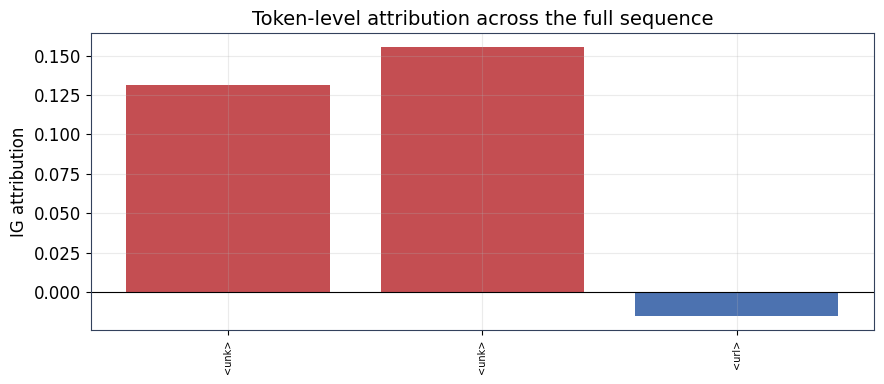

In [60]:
if RUN_IG and "CustomHybridAttnBiGRU" in FITTED_MODELS:
    try:
        from captum.attr import LayerIntegratedGradients
    except ImportError:
        print("[INFO] `captum` is not installed -- skipping. Install with: pip install -q captum")
        RUN_IG = False

if RUN_IG and "CustomHybridAttnBiGRU" in FITTED_MODELS:
    _ig_model = FITTED_MODELS["CustomHybridAttnBiGRU"].eval()

    def _ig_forward(token_ids, feats):
        logits, _ = _ig_model(token_ids, feats)
        return torch.sigmoid(logits).unsqueeze(-1)

    lig = LayerIntegratedGradients(_ig_forward, _ig_model.embedding)

    inv_vocab = {i: w for w, i in vocab.items()}
    _ig_row = next(i for i in range(len(test_df)) if test_df["label"].iloc[i] == 1)
    token_ids = torch.tensor([encode(test_df["text_clean"].iloc[_ig_row])], dtype=torch.long).to(DEVICE)
    feats_row = torch.tensor(test_feats.iloc[[_ig_row]].values, dtype=torch.float32).to(DEVICE)
    baseline_ids = torch.zeros_like(token_ids)  # all <pad>

    # Fix: cuDNN's fused RNN kernel does not save the buffers backward() needs
    # unless the module is running in training mode, so Captum's double-backward
    # through the GRU raises "cudnn RNN backward can only be called in training
    # mode" here even though _ig_model is correctly eval()'d (eval mode is still
    # required so dropout stays off). Disabling cuDNN for just this call forces
    # PyTorch's native (non-fused) RNN backward, which supports eval-mode
    # backward fine -- slower for this one attribution call, but correct and
    # numerically equivalent.
    with torch.backends.cudnn.flags(enabled=False):
        attributions, _ = lig.attribute(
            inputs=token_ids, baselines=baseline_ids, additional_forward_args=(feats_row,),
            n_steps=32, return_convergence_delta=True)
    token_attr = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()

    tokens = [inv_vocab.get(t, "<unk>") for t in token_ids.squeeze(0).cpu().numpy()]
    real_len = int((token_ids.squeeze(0).cpu().numpy() != 0).sum())
    pairs = list(zip(tokens[:real_len], token_attr[:real_len]))
    top_pairs = sorted(pairs, key=lambda x: -abs(x[1]))[:15]

    print(f"Integrated Gradients -- top-15 influential tokens, test email {_ig_row} "
          f"(true label=phishing):")
    for tok, attr in top_pairs:
        direction = "-> phishing" if attr > 0 else "-> legit"
        print(f"  {tok:20s} attribution={attr:+.4f}  {direction}")

    fig, ax = plt.subplots(figsize=(9, 4))
    words, attrs = zip(*pairs) if pairs else ([], [])
    colors = ["#C44E52" if a > 0 else "#4C72B0" for a in attrs]
    ax.bar(range(len(words)), attrs, color=colors)
    ax.set_xticks(range(len(words))); ax.set_xticklabels(words, rotation=90, fontsize=7)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("IG attribution")
    ax.set_title("Token-level attribution across the full sequence")
    plt.tight_layout()
    plt.savefig(WORKING_DIR / "plots" / "integrated_gradients_example.png", dpi=130)
    plt.show()
else:
    print("RUN_IG is False, or the custom hybrid model was not trained -- skipping Integrated Gradients.")


### 16.3 Integrated Gradients for the Winning Transformer

Section 16.2's Integrated Gradients only ever covered the custom BiGRU,
because a Transformer's fine-tuned weights weren't reloadable after training
(see Section 12.1). Now that any Transformer's winning
checkpoint can be reloaded from disk, we add real token-level IG for
`BEST_MODEL_NAME` specifically when it is one of the Transformers -- giving
the *actual* deployed model an explanation method, not just a stand-in.

Integrated Gradients -- RoBERTa-base (the actual winning model), top-15 tokens, test email 0 (true label=phishing), IG convergence delta=-0.4615:
  new                  attribution=+0.0004  -> phishing
  ides                 attribution=+0.0004  -> phishing
  </s>                 attribution=+0.0003  -> phishing
  products             attribution=-0.0002  -> legit
  Ġ<                   attribution=-0.0002  -> legit
  w                    attribution=+0.0002  -> phishing
  products             attribution=-0.0002  -> legit
  >                    attribution=-0.0001  -> legit
  Ġproduct             attribution=+0.0001  -> phishing
  url                  attribution=-0.0001  -> legit
  world                attribution=-0.0001  -> legit
  es                   attribution=+0.0001  -> phishing
  af                   attribution=-0.0001  -> legit
  ec                   attribution=+0.0000  -> phishing
  <s>                  attribution=+0.0000  -> phishing


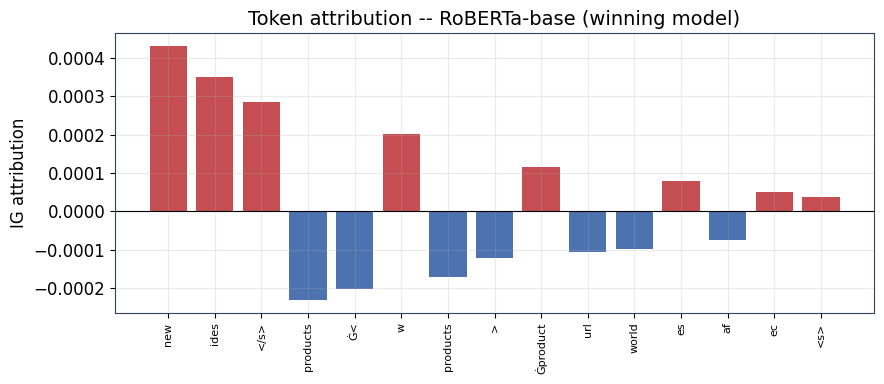

In [61]:
if RUN_IG and BEST_MODEL_NAME in TRANSFORMER_CKPT_MAP:
    try:
        from captum.attr import LayerIntegratedGradients as _TransformerLIG
    except ImportError:
        print("[INFO] `captum` is not installed -- skipping Transformer IG.")
    else:
        run_name = TRANSFORMER_CKPT_MAP[BEST_MODEL_NAME]
        ckpt_root = WORKING_DIR / "models" / f"{run_name}_ckpt"
        ckpt_dirs = sorted(ckpt_root.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[-1]))
        if not ckpt_dirs:
            print(f"[INFO] No checkpoint found for '{BEST_MODEL_NAME}' -- skipping Transformer IG.")
        else:
            if run_name not in _TRANSFORMER_MODEL_CACHE:
                from transformers import AutoTokenizer as _AT2, AutoModelForSequenceClassification as _AS2
                _tok_ig = _AT2.from_pretrained(ckpt_dirs[-1])
                _mdl_ig = _AS2.from_pretrained(ckpt_dirs[-1]).to(DEVICE).eval()
                _TRANSFORMER_MODEL_CACHE[run_name] = (_tok_ig, _mdl_ig)
            _tok_ig, _mdl_ig = _TRANSFORMER_MODEL_CACHE[run_name]

            _ig_row_t = next(i for i in range(len(test_df)) if test_df["label"].iloc[i] == 1)
            _ig_text = test_df["text_clean"].iloc[_ig_row_t]
            _enc = _tok_ig(_ig_text, truncation=True, max_length=256, return_tensors="pt").to(DEVICE)
            _input_ids = _enc["input_ids"]
            _attn_mask = _enc["attention_mask"]
            _baseline_ids = torch.full_like(_input_ids, _tok_ig.pad_token_id or 0)

            def _t_forward(input_ids, attention_mask):
                return torch.softmax(_mdl_ig(input_ids=input_ids, attention_mask=attention_mask).logits, dim=-1)[:, 1]

            _embed_layer = _mdl_ig.get_input_embeddings()
            _lig_t = _TransformerLIG(_t_forward, _embed_layer)
            _attributions, _delta = _lig_t.attribute(
                inputs=_input_ids, baselines=_baseline_ids,
                additional_forward_args=(_attn_mask,), n_steps=24,
                return_convergence_delta=True)
            _tok_attr = _attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
            _tokens_t = _tok_ig.convert_ids_to_tokens(_input_ids.squeeze(0).cpu().numpy())

            _pairs_t = sorted(zip(_tokens_t, _tok_attr), key=lambda x: -abs(x[1]))[:15]
            print(f"Integrated Gradients -- {display_name(BEST_MODEL_NAME)} (the actual winning model), "
                  f"top-15 tokens, test email {_ig_row_t} (true label=phishing), "
                  f"IG convergence delta={float(_delta):.4f}:")
            for tok, attr in _pairs_t:
                direction = "-> phishing" if attr > 0 else "-> legit"
                print(f"  {tok:20s} attribution={attr:+.4f}  {direction}")

            fig, ax = plt.subplots(figsize=(9, 4))
            words_t, attrs_t = zip(*_pairs_t) if _pairs_t else ([], [])
            colors_t = ["#C44E52" if a > 0 else "#4C72B0" for a in attrs_t]
            ax.bar(range(len(words_t)), attrs_t, color=colors_t)
            ax.set_xticks(range(len(words_t))); ax.set_xticklabels(words_t, rotation=90, fontsize=8)
            ax.axhline(0, color="black", linewidth=0.8)
            ax.set_ylabel("IG attribution")
            ax.set_title(f"Token attribution -- {display_name(BEST_MODEL_NAME)} (winning model)")
            plt.tight_layout()
            plt.savefig(WORKING_DIR / "plots" / "integrated_gradients_best_transformer.png", dpi=130)
            plt.show()
elif RUN_IG:
    print(f"[INFO] BEST_MODEL_NAME ('{BEST_MODEL_NAME}') is not a Transformer -- "
          "Section 16.2's BiGRU IG (if applicable) or 16.1's SHAP already covers "
          "the winning model family; skipping the Transformer-specific IG branch.")


---

[← Model Development, Benchmark & Ensembles](02_model_development_and_ensembles.ipynb) · [Next: Threat Intelligence: Tactics & IOCs →](04_threat_intelligence_tactics_and_iocs.ipynb)